In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Copy this into a Colab cell and run it first
!pip install shap optuna --quiet


# ────────────────────────────────────────────────────────────
# CELL 2 — Upload your data file
# ────────────────────────────────────────────────────────────

"""
from google.colab import files
uploaded = files.upload()   # select tbi_final_features_v6
"""

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 17.4 MB/s eta 0:00:00


'\nfrom google.colab import files\nuploaded = files.upload()   # select tbi_final_features_v6\n'

In [4]:
# ============================================================
# TBI SEVERITY PREDICTION — FULL GPU PIPELINE
# Google Colab T4 Ready
# ============================================================
# BEFORE RUNNING:
#   Runtime → Change runtime type → T4 GPU → Save
#
# Run each cell in order: Cell 1 → 2 → 3 → ... → 10
# ============================================================


# ────────────────────────────────────────────────────────────
# CELL 1 — Install dependencies
# ────────────────────────────────────────────────────────────
"""
!pip install shap optuna xgboost --quiet
"""


# ────────────────────────────────────────────────────────────
# CELL 2 — Upload your data file
# ────────────────────────────────────────────────────────────
"""
from google.colab import files
uploaded = files.upload()   # select tbi_final_features_v6
"""


# ────────────────────────────────────────────────────────────
# CELL 3 — Imports + GPU check
# ────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import subprocess
import os
warnings.filterwarnings("ignore")

from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (StratifiedKFold, cross_validate,
                                      train_test_split, cross_val_score)
from sklearn.feature_selection import (SelectKBest, f_classif,
                                        mutual_info_classif, RFE)
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.utils.multiclass import type_of_target
import xgboost as xgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from IPython.display import display, Image

# ── GPU check ────────────────────────────────────────────────
def check_gpu():
    try:
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=name,memory.total",
             "--format=csv,noheader"],
            capture_output=True, text=True, timeout=5
        )
        if result.returncode == 0:
            print(f"✓ GPU detected: {result.stdout.strip()}")
            return True
        else:
            print("⚠ No GPU detected — running on CPU")
            print("  Go to: Runtime → Change runtime type → T4 GPU → Save")
            return False
    except Exception:
        print("⚠ Could not detect GPU — running on CPU")
        return False

GPU_AVAILABLE = check_gpu()
DEVICE        = "cuda" if GPU_AVAILABLE else "cpu"
TREE_METHOD   = "hist"   # works on both GPU and CPU in XGBoost >= 2.0
print(f"✓ XGBoost will run on: {DEVICE.upper()}")
print("✓ All imports successful")


# ────────────────────────────────────────────────────────────
# CELL 4 — Configuration
# ────────────────────────────────────────────────────────────

DATA_FILE   = "TBi_3205_Allfeature.csv"   # ← your file name
TARGET_COL  = "tbi_severity"
RANDOM_SEED = 42
N_FOLDS     = 5
ICU_ONLY    = True

COAG_COLS = ["pt_avg", "ptt_avg"]
COAG_FLAGS = [f"{c}_missing" for c in COAG_COLS]

LAB_COLS = [
     "wbc_avg",
     "creatinine_avg",
     "glucose_avg",
     "platelets_avg",
     "anion_gap_avg",
     "sodium_avg",
     "potassium_avg",
     "rbc_avg",
]

VITAL_COLS = [
    "heart_rate_avg",
    "resp_rate_avg",
    "dbp_avg",
    "spo2_avg",
]

#SEVERITY_COLS    = ["apsiii", "oasis", "sapsii", "sofa"]#
COMORBIDITY_COLS = ["CHF", "liver", "chronic_lung_disease",
                    "CVD", "malignant", "AKI", "CCI"]
STABLE_COLS      = COMORBIDITY_COLS
ICU_COLS         = VITAL_COLS
GCS_COLS         = [ "gcs_total_avg"]
CLASS_NAMES      = ["Mild", "Moderate", "Severe"]

print("✓ Configuration set")


# ────────────────────────────────────────────────────────────
# CELL 5 — Load, impute, prepare data
# ────────────────────────────────────────────────────────────

print("=" * 60)
print("STEP 1 — Loading & Preparing Data")
print("=" * 60)

df = pd.read_csv(DATA_FILE)
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

# ── Derive TBI severity from GCS ─────────────────────────────
def get_severity(gcs):
    if pd.isna(gcs): return np.nan
    elif gcs >= 13:  return 0   # Mild
    elif gcs >= 9:   return 1   # Moderate
    else:            return 2   # Severe

df["tbi_severity"] = df["gcs_total_min"].apply(get_severity)

print("\nTBI Severity distribution:")
counts = df["tbi_severity"].value_counts().sort_index()
for i, name in enumerate(CLASS_NAMES):
    n = int(counts.get(i, 0))
    print(f"  {name:>10} (GCS {['13-15','9-12','3-8'][i]}): "
          f"{n:,} ({n/len(df)*100:.1f}%)")

# ── Missingness flags for PT/PTT ─────────────────────────────
for col in COAG_COLS:
    df[f"{col}_missing"] = df[col].isna().astype(int)

# ── Single cohort: ICU only (3205 rows) ────────────────────────
# Your file is ICU-only, so we don't split into ICU vs non-ICU.
# Keep icu_flag for consistency with later code.
df["icu_flag"] = 1
print(f"\nICU patients (single cohort): {len(df):,}")

# ── Fast KNN imputation (single pass) ─────────────────────────
print("\nImputing missing values (KNN — fast) on ICU-only cohort...")

def fast_impute(data, target_cols, predictor_cols):
    cols   = [c for c in predictor_cols + target_cols if c in data.columns]
    subset = data[cols].select_dtypes(include=[np.number])
    arr    = KNNImputer(n_neighbors=5).fit_transform(subset)
    imp_df = pd.DataFrame(arr, columns=subset.columns, index=data.index)
    result = data.copy()
    for col in target_cols:
        if col in imp_df.columns:
            result[col] = imp_df[col]
    return result

# ICU cohort gets labs + coags + ICU vitals/scores (same as your old ICU branch)
df_imputed = fast_impute(
    df.copy(),
    target_cols=LAB_COLS + COAG_COLS + ICU_COLS,
    predictor_cols=STABLE_COLS
)

df_imputed.to_csv("tbi_imputed.csv", index=False)
print("✓ Imputation complete — saved: tbi_imputed.csv")

# ── Continue with same pipeline downstream ─────────────────────
df_model = df_imputed.copy()


df_model = df_model[df_model[TARGET_COL].notna()].copy()
df_model[TARGET_COL] = df_model[TARGET_COL].astype(int)
print(f"After dropping missing target: {len(df_model):,} patients")

df_model["sex_enc"] = (df_model["sex"] == "M").astype(int)

def encode_race(r):
    if pd.isna(r): return "unknown"
    r = str(r).upper()
    if "WHITE"    in r: return "white"
    if "BLACK"    in r: return "black"
    if "HISPANIC" in r: return "hispanic"
    if "ASIAN"    in r: return "asian"
    return "other"

df_model["race_grp"] = df_model["race"].apply(encode_race)
race_dummies = pd.get_dummies(df_model["race_grp"], prefix="race", drop_first=True)
df_model     = pd.concat([df_model, race_dummies], axis=1)
RACE_COLS    = race_dummies.columns.tolist()

# ── Feature matrix — NO GCS (avoids leakage) ─────────────────
ALL_FEATURES = (COMORBIDITY_COLS + VITAL_COLS + LAB_COLS +
                COAG_COLS + COAG_FLAGS +
                ["sex_enc", "MST"] + RACE_COLS)
ALL_FEATURES = [c for c in ALL_FEATURES
                if c in df_model.columns and c not in GCS_COLS]

X_full = df_model[ALL_FEATURES].copy()
keep   = X_full.columns[X_full.isnull().mean() < 0.5]
X_full = X_full[keep].fillna(X_full.median(numeric_only=True))

# Clean integer target, reset index
y      = pd.Series(np.array(df_model[TARGET_COL]).astype(int))
X_full = X_full.reset_index(drop=True)

# Verify target type
assert type_of_target(y) == "multiclass", \
    f"Target is '{type_of_target(y)}' — expected 'multiclass'"
print(f"\n✓ Target type: {type_of_target(y)}")
print(f"✓ Feature matrix: {X_full.shape[1]} features × {X_full.shape[0]:,} patients")
print("\nClass distribution:")
for i, name in enumerate(CLASS_NAMES):
    n = (y == i).sum()
    print(f"  {name:>10}: {n:,} ({n/len(y)*100:.1f}%)")


# ────────────────────────────────────────────────────────────
# CELL 6 — Feature selection
# ────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 2 — Feature Selection")
print("=" * 60)

cv_strat = StratifiedKFold(n_splits=N_FOLDS, shuffle=True,
                            random_state=RANDOM_SEED)

f_scores  = pd.Series(
    SelectKBest(f_classif, k="all").fit(X_full, y).scores_,
    index=X_full.columns).sort_values(ascending=False)

mi_scores = pd.Series(
    SelectKBest(mutual_info_classif, k="all").fit(X_full, y).scores_,
    index=X_full.columns).sort_values(ascending=False)

rf_sel = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                  random_state=RANDOM_SEED, n_jobs=-1)
rf_sel.fit(X_full, y)
rf_scores = pd.Series(rf_sel.feature_importances_,
                       index=X_full.columns).sort_values(ascending=False)

rfe = RFE(RandomForestClassifier(n_estimators=50, random_state=RANDOM_SEED),
           n_features_to_select=20, step=5)
rfe.fit(X_full, y)
rfe_selected = X_full.columns[rfe.support_].tolist()

consensus = pd.DataFrame({
    "f_rank":   f_scores.rank(ascending=False),
    "mi_rank":  mi_scores.rank(ascending=False),
    "rf_rank":  rf_scores.rank(ascending=False),
    "rfe_rank": pd.Series({c: (1 if c in rfe_selected
                               else len(X_full.columns))
                            for c in X_full.columns}),
})
consensus["mean_rank"] = consensus.mean(axis=1)
consensus = consensus.sort_values("mean_rank")
consensus.to_csv("feature_selection_results.csv")

TOP_FEATURES = consensus.head(20).index.tolist()
X_selected   = X_full[TOP_FEATURES]

print(f"\nTop 20 features (consensus):")
for i, f in enumerate(TOP_FEATURES, 1):
    print(f"  {i:>2}. {f}")

# Feature selection plot
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.patch.set_facecolor("#0a0d12")
for ax, (scores, title, color) in zip(axes, [
    (rf_scores.head(20),  "RF Importance",      "#00d4ff"),
    (mi_scores.head(20),  "Mutual Information",  "#ff6b35"),
    (f_scores.head(20),   "F-Statistic",         "#7fff6b"),
]):
    ax.barh(range(len(scores)), scores.values[::-1], color=color, alpha=0.85)
    ax.set_yticks(range(len(scores)))
    ax.set_yticklabels(scores.index[::-1], fontsize=8)
    ax.set_title(title, fontsize=10, color="white")
    ax.set_facecolor("#111620")
    ax.tick_params(colors="gray")
    ax.spines[:].set_color("#252d3d")
plt.suptitle("Feature Selection — TBI Severity", color="white", fontsize=13)
plt.tight_layout()
plt.savefig("feature_selection.png", dpi=120,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("\n✓ Saved: feature_selection.png")


# ────────────────────────────────────────────────────────────
# CELL 7 — Model training (GPU XGBoost + baselines)
# ────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print(f"STEP 3 — Model Training (XGBoost on {DEVICE.upper()} + Baselines)")
print("=" * 60)

scoring = {
    "AUC-ROC":  "roc_auc_ovr_weighted",
    "Accuracy": "accuracy",
    "F1":       "f1_weighted",
}

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000,
                                    class_weight="balanced",
                                    multi_class="multinomial",
                                    random_state=RANDOM_SEED)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced",
        random_state=RANDOM_SEED, n_jobs=-1,
    ),
    f"XGBoost ({DEVICE.upper()})": xgb.XGBClassifier(
        n_estimators     = 300,
        learning_rate    = 0.05,
        max_depth        = 6,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        tree_method      = TREE_METHOD,
        device           = DEVICE,
        objective        = "multi:softprob",
        num_class        = 3,
        eval_metric      = "mlogloss",
        random_state     = RANDOM_SEED,
        verbosity        = 0,
    ),
}

results = {}
print(f"\nRunning {N_FOLDS}-fold cross-validation...\n")

for name, model in models.items():
    print(f"  {name}...", end=" ", flush=True)
    cv_res = cross_validate(
        model, X_selected, y,
        cv=cv_strat, scoring=scoring,
        n_jobs=1 if "XGBoost" in name else -1,
    )
    results[name] = cv_res
    auc = cv_res["test_AUC-ROC"]
    print(f"AUC = {auc.mean():.3f} ± {auc.std():.3f}")

# Summary table
print(f"\n{'Model':<25}", end="")
for m in scoring: print(f"  {m:>18}", end="")
print()
print("-" * (25 + 20 * len(scoring)))
for name, res in results.items():
    print(f"{name:<25}", end="")
    for m in scoring:
        v = res[f"test_{m}"]
        print(f"  {v.mean():>8.3f} ±{v.std():>6.3f}", end="")
    print()

# CV plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor("#0a0d12")
colors = ["#00d4ff", "#ff6b35", "#7fff6b"]
for ax, metric in zip(axes, scoring.keys()):
    for i, (name, res) in enumerate(results.items()):
        vals = res[f"test_{metric}"]
        ax.boxplot(vals, positions=[i], widths=0.5,
                   patch_artist=True,
                   boxprops=dict(facecolor=colors[i], alpha=0.7),
                   medianprops=dict(color="white", linewidth=2),
                   whiskerprops=dict(color="gray"),
                   capprops=dict(color="gray"),
                   flierprops=dict(marker="o", color="gray", markersize=4))
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(list(models.keys()), rotation=15, ha="right", fontsize=8)
    ax.set_title(metric, color="white")
    ax.set_facecolor("#111620")
    ax.tick_params(colors="gray")
    ax.spines[:].set_color("#252d3d")
plt.suptitle(f"Cross-Validation — TBI Severity (XGBoost {DEVICE.upper()} vs Baselines)",
             color="white", fontsize=12)
plt.tight_layout()
plt.savefig("model_cv_results.png", dpi=120,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("\n✓ Saved: model_cv_results.png")


# ────────────────────────────────────────────────────────────
# CELL 7b — Hyperparameter tuning (Optuna + GPU XGBoost)
# ────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print(f"STEP 4 — Hyperparameter Tuning (Optuna + {DEVICE.upper()})")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2,
    random_state=RANDOM_SEED, stratify=y,
)

def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 600, step=50),
        "max_depth":         trial.suggest_int("max_depth", 3, 10),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "gamma":             trial.suggest_float("gamma", 0, 5),
        "reg_alpha":         trial.suggest_float("reg_alpha", 0, 2),
        "reg_lambda":        trial.suggest_float("reg_lambda", 0, 2),
        "tree_method":       TREE_METHOD,
        "device":            DEVICE,
        "objective":         "multi:softprob",
        "num_class":         3,
        "eval_metric":       "mlogloss",
        "random_state":      RANDOM_SEED,
        "verbosity":         0,
    }
    scores = cross_val_score(
        xgb.XGBClassifier(**params), X_train, y_train,
        cv=cv_strat, scoring="roc_auc_ovr_weighted", n_jobs=1,
    )
    return scores.mean()

print(f"\nRunning 80 Optuna trials on {DEVICE.upper()}...")
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
)
study.optimize(objective, n_trials=80, show_progress_bar=True)

best_params = study.best_params
best_params.update({
    "tree_method":  TREE_METHOD,
    "device":       DEVICE,
    "objective":    "multi:softprob",
    "num_class":    3,
    "eval_metric":  "mlogloss",
    "random_state": RANDOM_SEED,
    "verbosity":    0,
})

print(f"\n✓ Best AUC:    {study.best_value:.4f}")
print(f"  Best params: {best_params}")

# Train tuned model
xgb_tuned = xgb.XGBClassifier(**best_params)
xgb_tuned.fit(X_train, y_train)

y_prob_tuned = xgb_tuned.predict_proba(X_test)
y_bin        = label_binarize(y_test, classes=[0, 1, 2])
auc_tuned    = roc_auc_score(y_bin, y_prob_tuned,
                               multi_class="ovr", average="weighted")
print(f"\n✓ Tuned XGBoost test AUC: {auc_tuned:.4f}")

# Optuna plots
trial_values = [t.value for t in study.trials]
best_so_far  = pd.Series(trial_values).cummax()
param_imp    = optuna.importance.get_param_importances(study)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor("#0a0d12")
for ax in axes:
    ax.set_facecolor("#111620")
    ax.tick_params(colors="gray")
    ax.spines[:].set_color("#252d3d")

axes[0].scatter(range(len(trial_values)), trial_values,
                c="#00d4ff", s=15, alpha=0.5)
axes[0].plot(best_so_far.values, color="#ff6b35", lw=2, label="Best so far")
axes[0].set_xlabel("Trial", color="gray")
axes[0].set_ylabel("AUC-ROC", color="gray")
axes[0].set_title(f"Optuna Trials ({DEVICE.upper()})", color="white")
axes[0].legend(facecolor="#1a2030", labelcolor="white")

top_p = dict(list(param_imp.items())[:8])
axes[1].barh(list(top_p.keys()), list(top_p.values()),
             color="#7fff6b", alpha=0.8)
axes[1].set_title("Hyperparameter Importance", color="white")
axes[1].set_xlabel("Importance", color="gray")

plt.suptitle(f"Optuna Tuning — XGBoost on {DEVICE.upper()}",
             color="white", fontsize=12)
plt.tight_layout()
plt.savefig("optuna_tuning.png", dpi=120,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: optuna_tuning.png")


# ────────────────────────────────────────────────────────────
# CELL 8 — SHAP Analysis
# ────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 5 — SHAP Analysis")
print("=" * 60)

print("\nComputing SHAP values...")
explainer   = shap.TreeExplainer(xgb_tuned)
# Fix: Convert X_test to numpy array to ensure correct feature handling by SHAP
shap_values = explainer.shap_values(X_test.values)
print("✓ SHAP values computed")

# ── Global importance ─────────────────────────────────────────
# Use len(CLASS_NAMES) for robustness instead of hardcoded 3
mean_abs_shap = np.mean([np.abs(shap_values[i]).mean(axis=0)
                          for i in range(len(CLASS_NAMES))], axis=0)
global_imp = pd.Series(mean_abs_shap,
                        index=TOP_FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor("#0a0d12")
ax.set_facecolor("#111620")
colors_imp = plt.cm.cool(np.linspace(0.2, 0.9, len(global_imp)))
ax.barh(range(len(global_imp)), global_imp.values[::-1],
        color=colors_imp[::-1], alpha=0.9)
ax.set_yticks(range(len(global_imp)))
ax.set_yticklabels(global_imp.index[::-1], fontsize=9)
ax.set_xlabel("Mean |SHAP| (averaged across classes)", color="gray")
ax.set_title("Global Feature Importance — TBI Severity (XGBoost)",
             color="white", fontsize=12)
ax.tick_params(colors="gray")
ax.spines[:].set_color("#252d3d")
plt.tight_layout()
plt.savefig("shap_global_importance.png", dpi=120,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: shap_global_importance.png")

# ── Beeswarm — one per severity class ────────────────────────
for i, class_name in enumerate(CLASS_NAMES):
    plt.figure(figsize=(11, 7))
    plt.gcf().patch.set_facecolor("#0a0d12")
    # Use X_test DataFrame here for feature names, but ensure shap_values[i] has correct dimensions
    shap.summary_plot(shap_values[i], X_test, # X_test is fine here for feature value mapping
                      feature_names=TOP_FEATURES,
                      show=False, plot_size=None)
    plt.title(f"SHAP Beeswarm — {class_name} TBI",
              color="white", fontsize=12, pad=12)
    plt.gca().set_facecolor("#111620")
    plt.gca().tick_params(colors="gray")
    plt.tight_layout()
    fname = f"shap_beeswarm_{class_name.lower()}.png"
    plt.savefig(fname, dpi=120, bbox_inches="tight", facecolor="#0a0d12")
    plt.close()
    print(f"✓ Saved: {fname}")

# ── Dependence plots — top 4, Severe class ───────────────────
top4      = global_imp.head(4).index.tolist()
sv_severe = shap_values[CLASS_NAMES.index('Severe')] # Access SHAP values for Severe class
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.patch.set_facecolor("#0a0d12")
axes = axes.flatten()

for i, feat in enumerate(top4):
    ax       = axes[i]
    fi       = TOP_FEATURES.index(feat)
    interact = global_imp.drop(feat).idxmax()
    sc = ax.scatter(X_test[feat].values, sv_severe[:, fi],
                    c=X_test[interact].values,
                    cmap="cool", s=8, alpha=0.5)
    ax.axhline(0, color="white", lw=0.7, alpha=0.3, linestyle="--")
    ax.set_xlabel(feat, color="gray", fontsize=9)
    ax.set_ylabel("SHAP (Severe)", color="gray", fontsize=9)
    ax.set_title(f"{feat}  (color={interact})", color="white", fontsize=9)
    ax.set_facecolor("#111620")
    ax.tick_params(colors="gray", labelsize=7)
    ax.spines[:].set_color("#252d3d")
    plt.colorbar(sc, ax=ax).ax.tick_params(colors="gray", labelsize=7)

plt.suptitle("SHAP Dependence — Severe TBI (Top 4 Features)",
             color="white", fontsize=12)
plt.tight_layout()
plt.savefig("shap_dependence.png", dpi=120,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: shap_dependence.png")

# ── Local explanations — high-risk patient per class ─────────
proba = xgb_tuned.predict_proba(X_test)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor("#0a0d12")

for i, (cname, color) in enumerate(
        zip(CLASS_NAMES, ["#7fff6b", "#ffbb33", "#ff4444"])):
    ax      = axes[i]
    pidx    = np.argmax(proba[:, i])
    sv_p    = shap_values[i][pidx]
    fv_p    = X_test.iloc[pidx] # Use X_test DataFrame for feature values
    order   = np.argsort(np.abs(sv_p))[::-1][:12]
    labels  = [f"{TOP_FEATURES[j]} = {fv_p.iloc[j]:.2f}" for j in order]
    vals    = sv_p[order]
    bcolors = ["#ff4444" if v > 0 else "#00d4ff" for v in vals]
    ax.barh(range(len(vals)), vals[::-1], color=bcolors[::-1], alpha=0.85)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(labels[::-1], fontsize=7)
    ax.axvline(0, color="white", lw=0.8, alpha=0.4)
    ax.set_title(f"High-Risk {cname}\n(p={proba[pidx, i]:.2f})",
                 color=color, fontsize=10)
    ax.set_xlabel("SHAP value", color="gray", fontsize=8)
    ax.set_facecolor("#111620")
    ax.tick_params(colors="gray", labelsize=7)
    ax.spines[:].set_color("#252d3d")

plt.suptitle("Local SHAP — High-Risk Patient Per Severity Class",
             color="white", fontsize=12)
plt.tight_layout()
plt.savefig("shap_local.png", dpi=120,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: shap_local.png")

# ── SHAP correlation heatmap ──────────────────────────────────
top10     = global_imp.head(10).index.tolist()
sv_all    = np.mean(shap_values, axis=0)
shap_corr = pd.DataFrame(sv_all, columns=TOP_FEATURES)[top10].corr()

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("#0a0d12")
ax.set_facecolor("#111620")
im = ax.imshow(shap_corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(top10)))
ax.set_xticklabels(top10, rotation=45, ha="right", fontsize=8, color="gray")
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10, fontsize=8, color="gray")
for ii in range(len(top10)):
    for jj in range(len(top10)):
        v = shap_corr.iloc[ii, jj]
        ax.text(jj, ii, f"{v:.2f}", ha="center", va="center",
                fontsize=7, color="white" if abs(v) > 0.5 else "gray")
plt.colorbar(im, ax=ax).ax.tick_params(colors="gray")
ax.set_title("SHAP Correlation — Top 10 Features",
             color="white", fontsize=11)
ax.spines[:].set_color("#252d3d")
plt.tight_layout()
plt.savefig("shap_correlation.png", dpi=120,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: shap_correlation.png")


# ────────────────────────────────────────────────────────────
# CELL 9 — Display all images
# ────────────────────────────────────────────────────────────

ALL_IMAGES = [
    ("Feature Selection",               "feature_selection.png"),
    ("Cross-Validation Results",        "model_cv_results.png"),
    ("Optuna Tuning",                   "optuna_tuning.png"),
    ("SHAP Global Importance",          "shap_global_importance.png"),
    ("SHAP Beeswarm — Mild TBI",        "shap_beeswarm_mild.png"),
    ("SHAP Beeswarm — Moderate TBI",    "shap_beeswarm_moderate.png"),
    ("SHAP Beeswarm — Severe TBI",      "shap_beeswarm_severe.png"),
    ("SHAP Dependence — Severe TBI",    "shap_dependence.png"),
    ("SHAP Local — High Risk Patients", "shap_local.png"),
    ("SHAP Correlation Heatmap",        "shap_correlation.png"),
]

print("\n" + "=" * 60)
print("ALL OUTPUT IMAGES")
print("=" * 60)

found, missing = 0, []
for title, fname in ALL_IMAGES:
    if os.path.exists(fname):
        print(f"\n{'─'*60}\n  {title}\n{'─'*60}")
        display(Image(filename=fname))
        found += 1
    else:
        missing.append(fname)

print(f"\n✓ Displayed {found}/{len(ALL_IMAGES)} images")
if missing:
    print(f"⚠ Not found: {missing}")
    print("  → Re-run the cell that generates the missing file")


# ────────────────────────────────────────────────────────────
# CELL 10 — Clinical summary
# ────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("CLINICAL SUMMARY")
print("=" * 60)
print(f"\nModel:  XGBoost (tuned, {DEVICE.upper()})")
print(f"Task:   TBI Severity — Mild / Moderate / Severe")
print(f"AUC-ROC (test set): {auc_tuned:.4f}")
print(f"\nTop 5 features driving severity prediction:")
for i, feat in enumerate(global_imp.head(5).index, 1):
    print(f"  {i}. {feat}")
print("""
How to read your plots:
  shap_beeswarm_severe.png  → What pushes a patient into Severe?
  shap_dependence.png       → At what threshold does risk jump?
  shap_local.png            → Why was THIS patient predicted Severe?
  shap_correlation.png      → Which features are redundant?

Next steps:
  → Calibration   : are predicted probabilities accurate?
  → Subgroup      : does performance differ by sex / race?
  → Validation    : test on a different hospital's data
""")

✓ GPU detected: Tesla T4, 15360 MiB
✓ XGBoost will run on: CUDA
✓ All imports successful
✓ Configuration set
STEP 1 — Loading & Preparing Data
Loaded: 3,205 rows × 67 columns

TBI Severity distribution:
        Mild (GCS 13-15): 1,297 (40.5%)
    Moderate (GCS 9-12): 442 (13.8%)
      Severe (GCS 3-8): 1,466 (45.7%)

ICU patients (single cohort): 3,205

Imputing missing values (KNN — fast) on ICU-only cohort...
✓ Imputation complete — saved: tbi_imputed.csv
After dropping missing target: 3,205 patients

✓ Target type: multiclass
✓ Feature matrix: 29 features × 3,205 patients

Class distribution:
        Mild: 1,297 (40.5%)
    Moderate: 442 (13.8%)
      Severe: 1,466 (45.7%)

STEP 2 — Feature Selection

Top 20 features (consensus):
   1. sodium_avg
   2. wbc_avg
   3. glucose_avg
   4. rbc_avg
   5. spo2_avg
   6. heart_rate_avg
   7. race_other
   8. pt_avg
   9. platelets_avg
  10. potassium_avg
  11. race_white
  12. ptt_avg
  13. dbp_avg
  14. anion_gap_avg
  15. creatinine_avg
  

  0%|          | 0/80 [00:00<?, ?it/s]


✓ Best AUC:    0.8069
  Best params: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.04086293695160871, 'subsample': 0.6817976686908028, 'colsample_bytree': 0.945442250431636, 'min_child_weight': 1, 'gamma': 1.3331516770293403, 'reg_alpha': 0.31607161780388715, 'reg_lambda': 1.120366070796686, 'tree_method': 'hist', 'device': 'cuda', 'objective': 'multi:softprob', 'num_class': 3, 'eval_metric': 'mlogloss', 'random_state': 42, 'verbosity': 0}

✓ Tuned XGBoost test AUC: 0.8093
✓ Saved: optuna_tuning.png

STEP 5 — SHAP Analysis

Computing SHAP values...
✓ SHAP values computed


ValueError: Length of values (3) does not match length of index (20)


STEP 5 — SHAP Analysis

Computing SHAP values...
  SHAP format: 3D array → split into 3 class arrays
✓ SHAP computed — 3 classes × 641 patients × 20 features
✓ Saved: shap_global_importance.png
✓ Saved: shap_beeswarm_mild.png
✓ Saved: shap_beeswarm_moderate.png
✓ Saved: shap_beeswarm_severe.png
✓ Saved: shap_dependence.png
✓ Saved: shap_local.png
✓ Saved: shap_correlation.png

ALL OUTPUT IMAGES

────────────────────────────────────────────────────────────
  Feature Selection
────────────────────────────────────────────────────────────


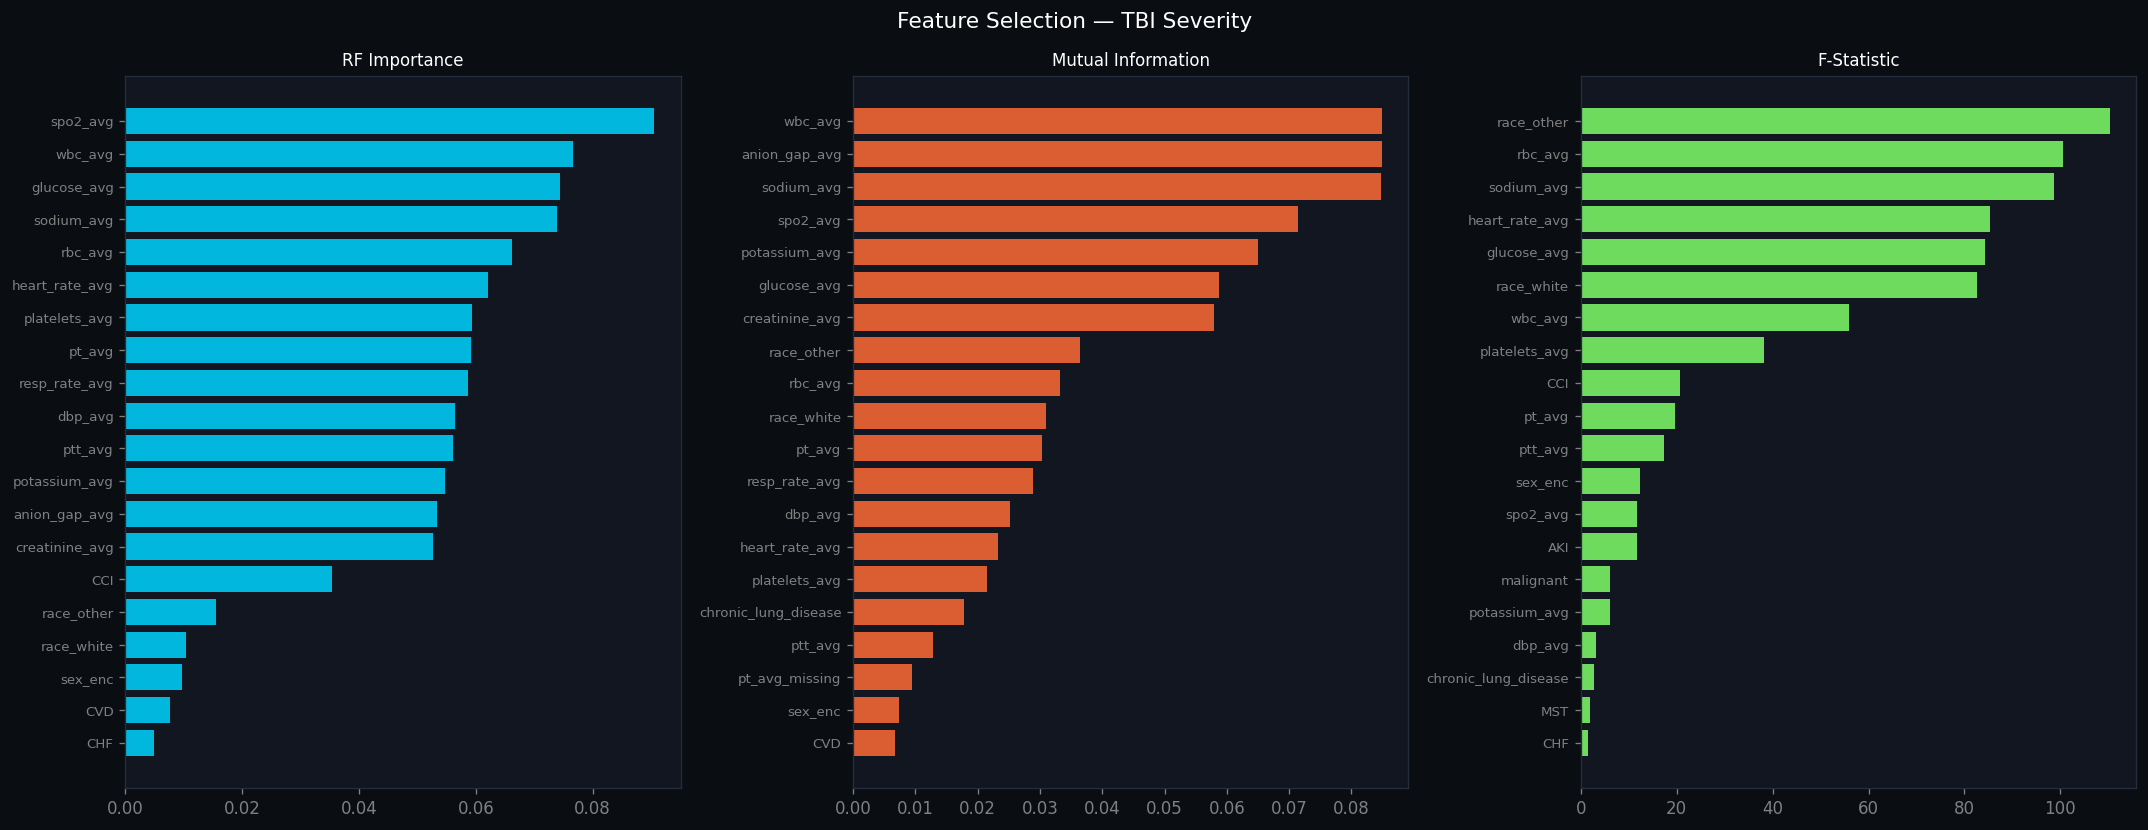


────────────────────────────────────────────────────────────
  Cross-Validation Results
────────────────────────────────────────────────────────────


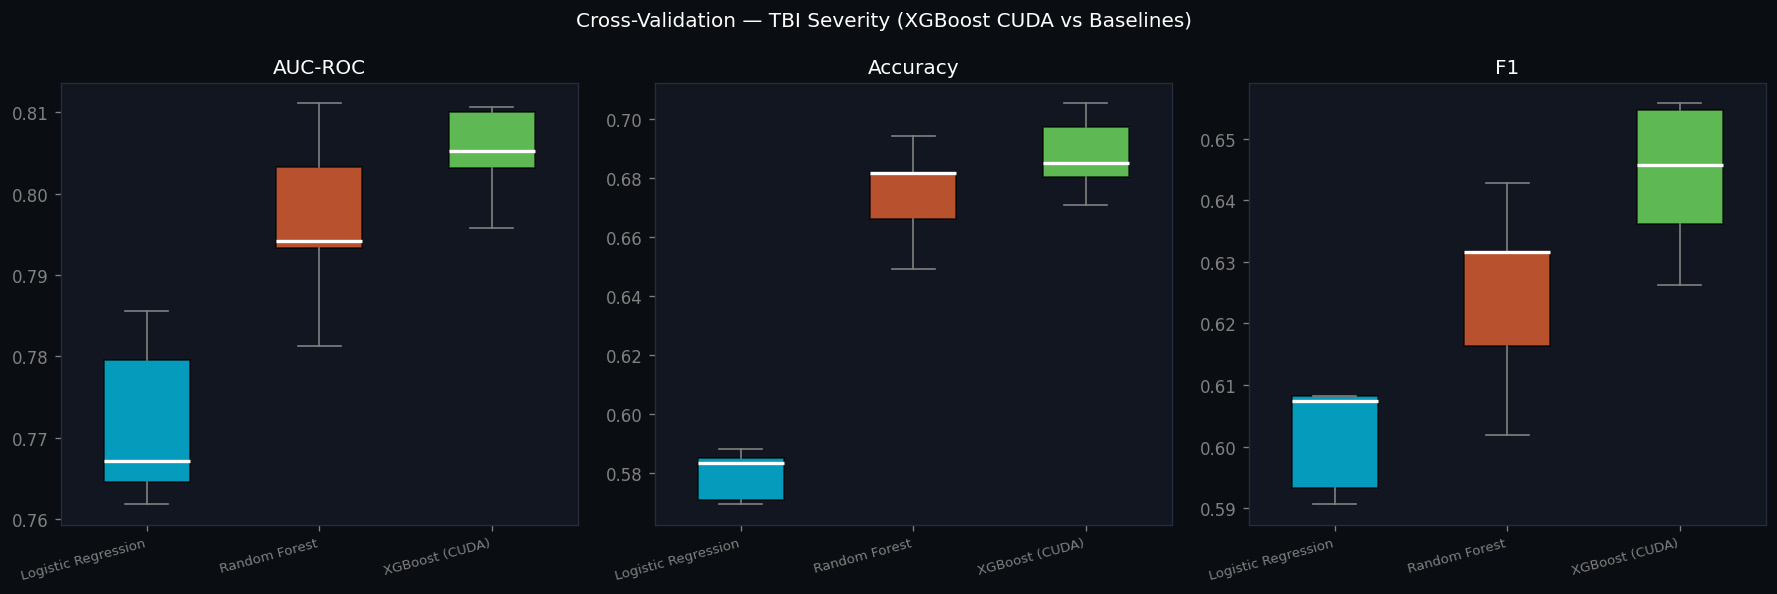


────────────────────────────────────────────────────────────
  Optuna Tuning
────────────────────────────────────────────────────────────


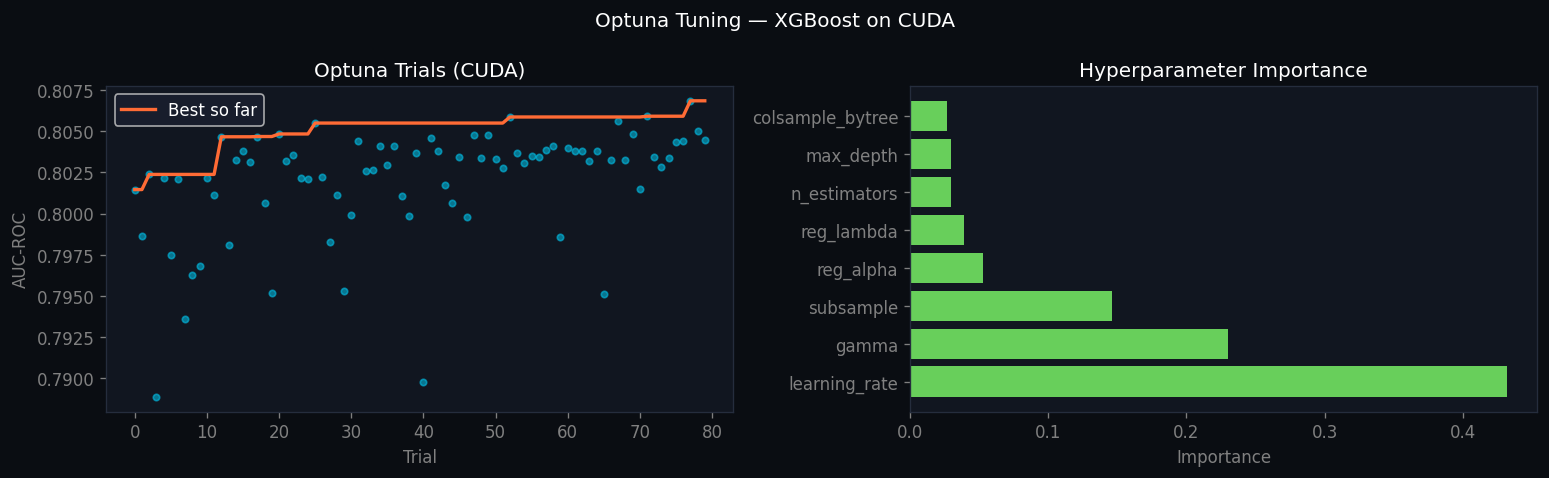


────────────────────────────────────────────────────────────
  SHAP Global Importance
────────────────────────────────────────────────────────────


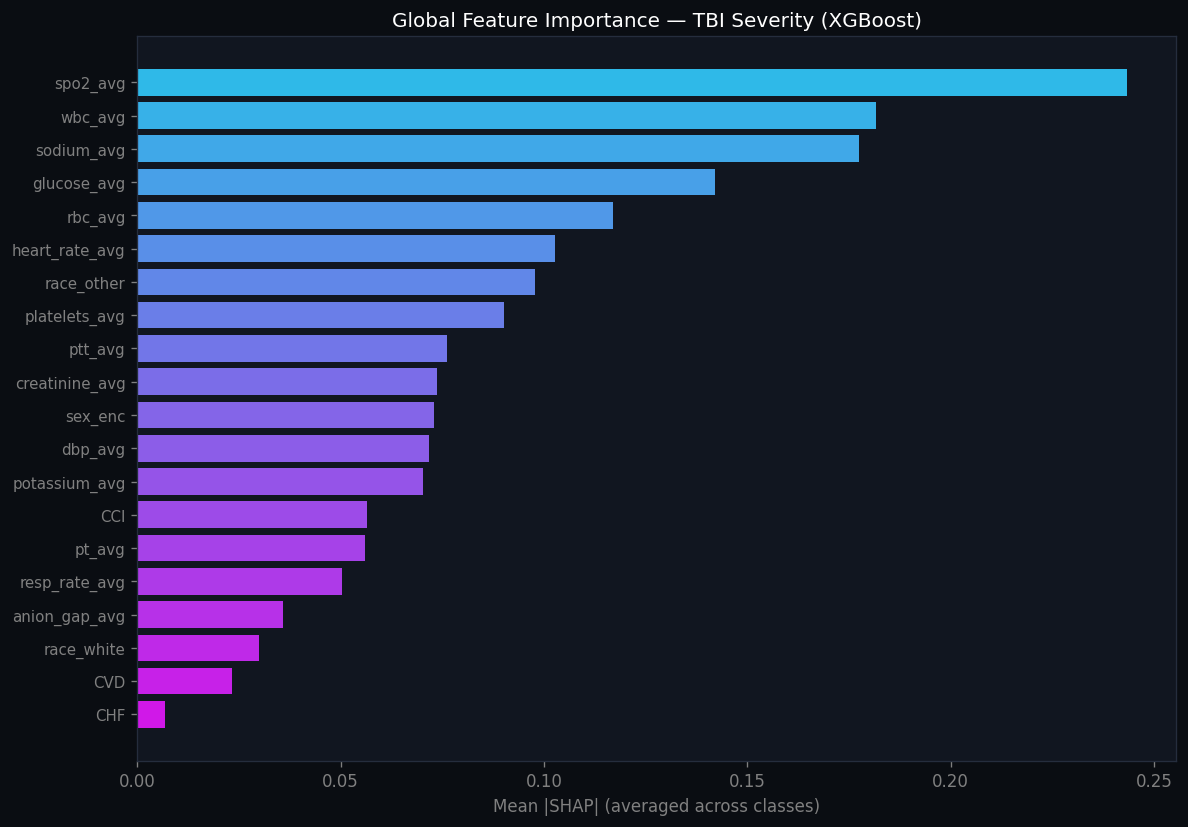


────────────────────────────────────────────────────────────
  SHAP Beeswarm — Mild TBI
────────────────────────────────────────────────────────────


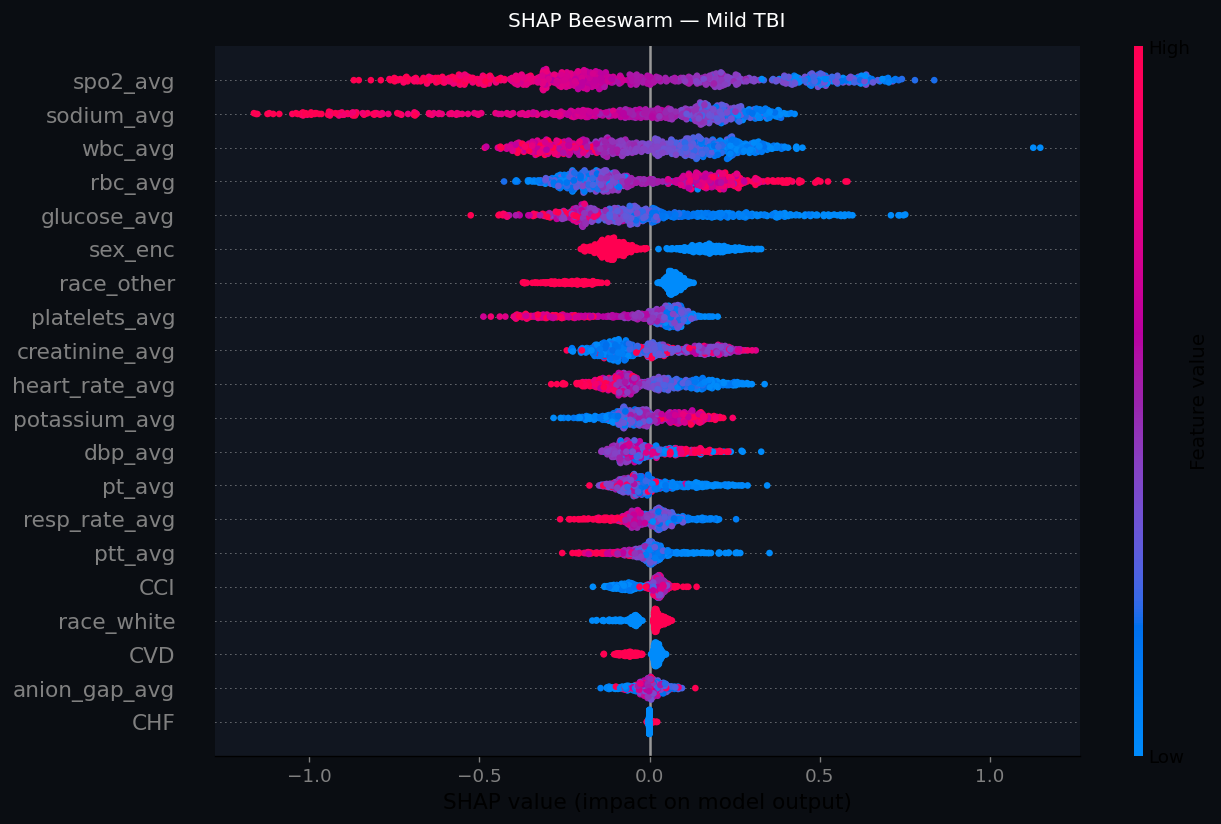


────────────────────────────────────────────────────────────
  SHAP Beeswarm — Moderate TBI
────────────────────────────────────────────────────────────


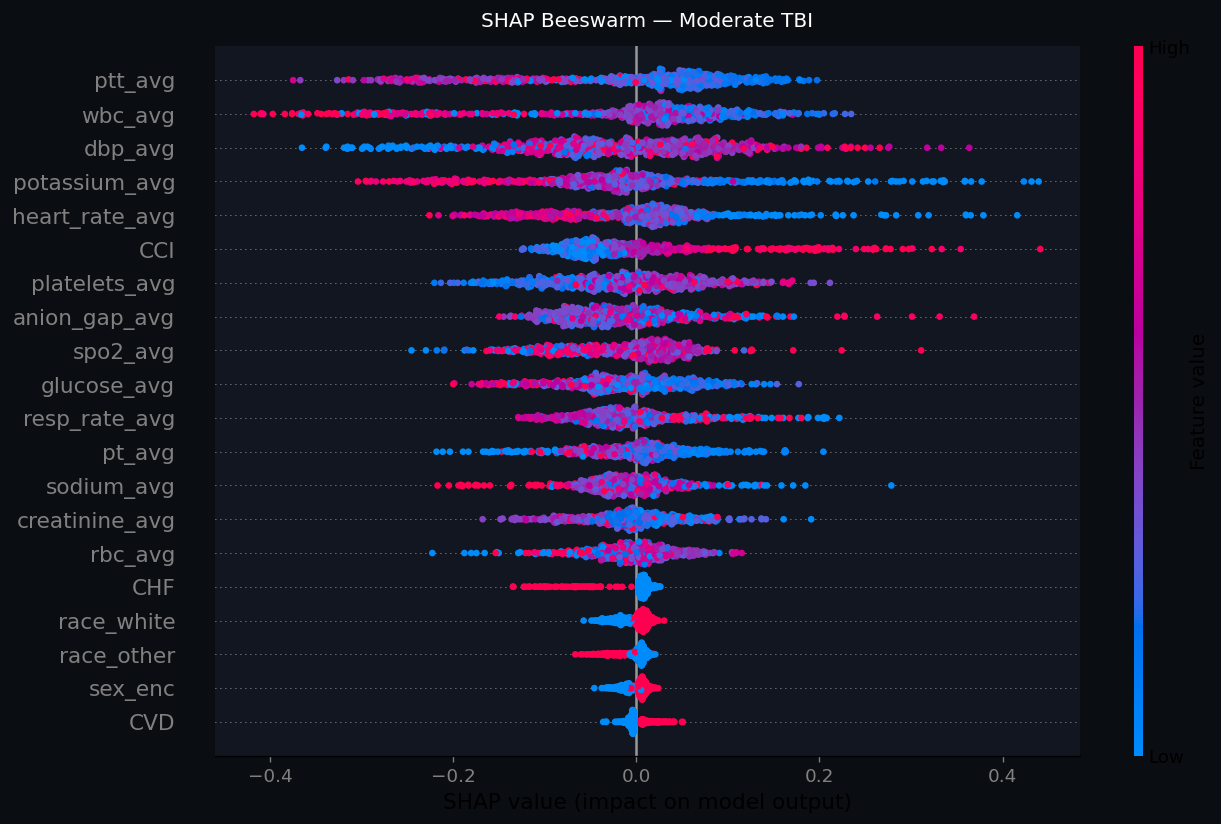


────────────────────────────────────────────────────────────
  SHAP Beeswarm — Severe TBI
────────────────────────────────────────────────────────────


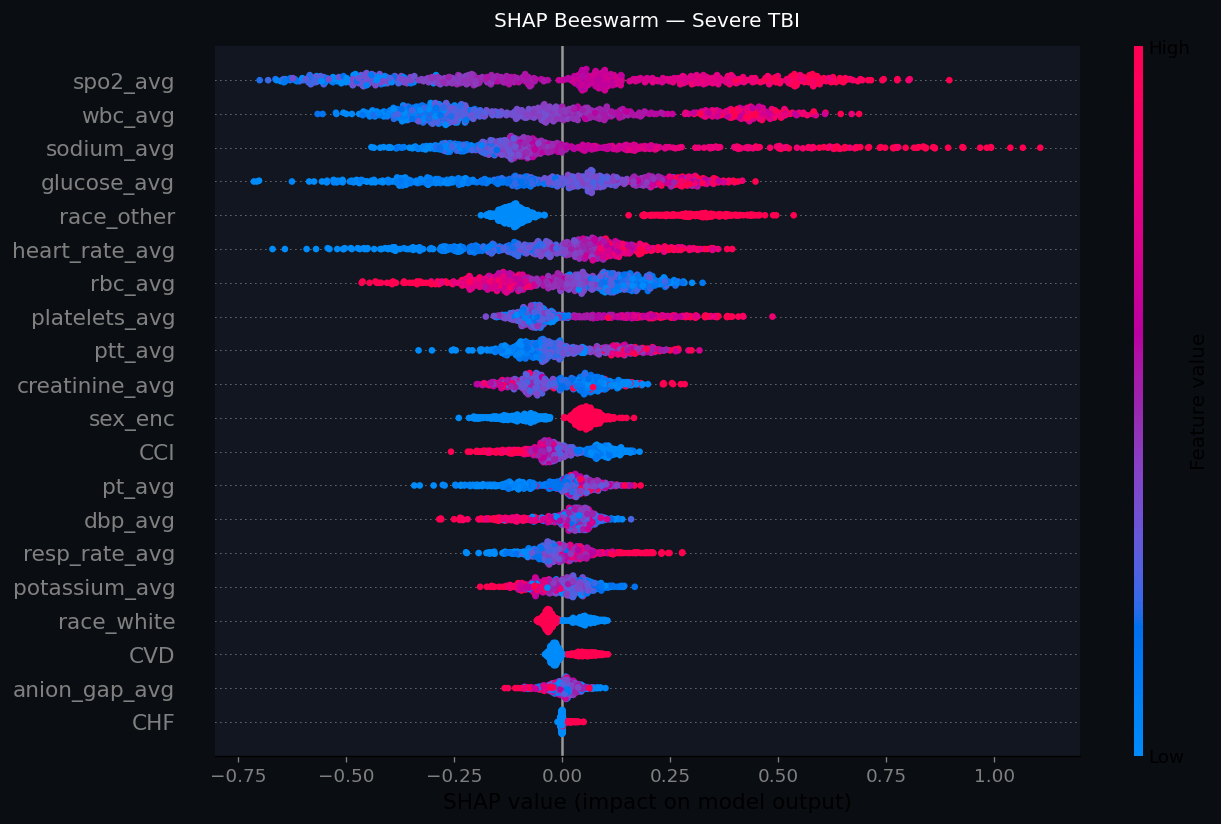


────────────────────────────────────────────────────────────
  SHAP Dependence — Severe TBI
────────────────────────────────────────────────────────────


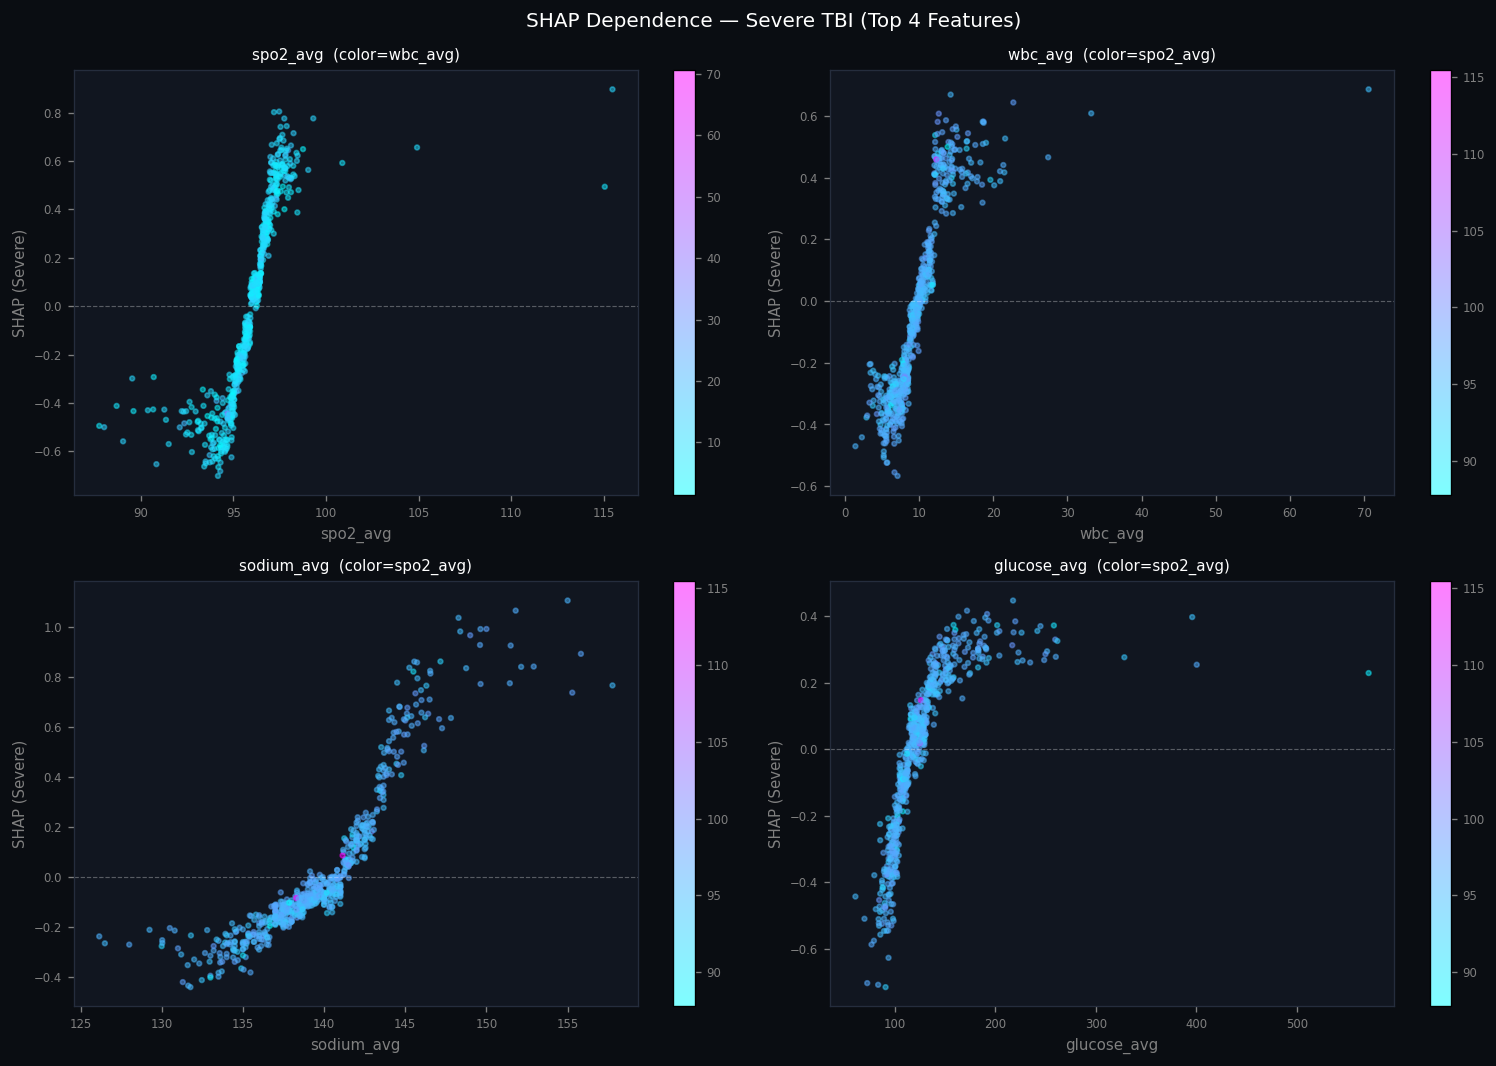


────────────────────────────────────────────────────────────
  SHAP Local — High Risk Patients
────────────────────────────────────────────────────────────


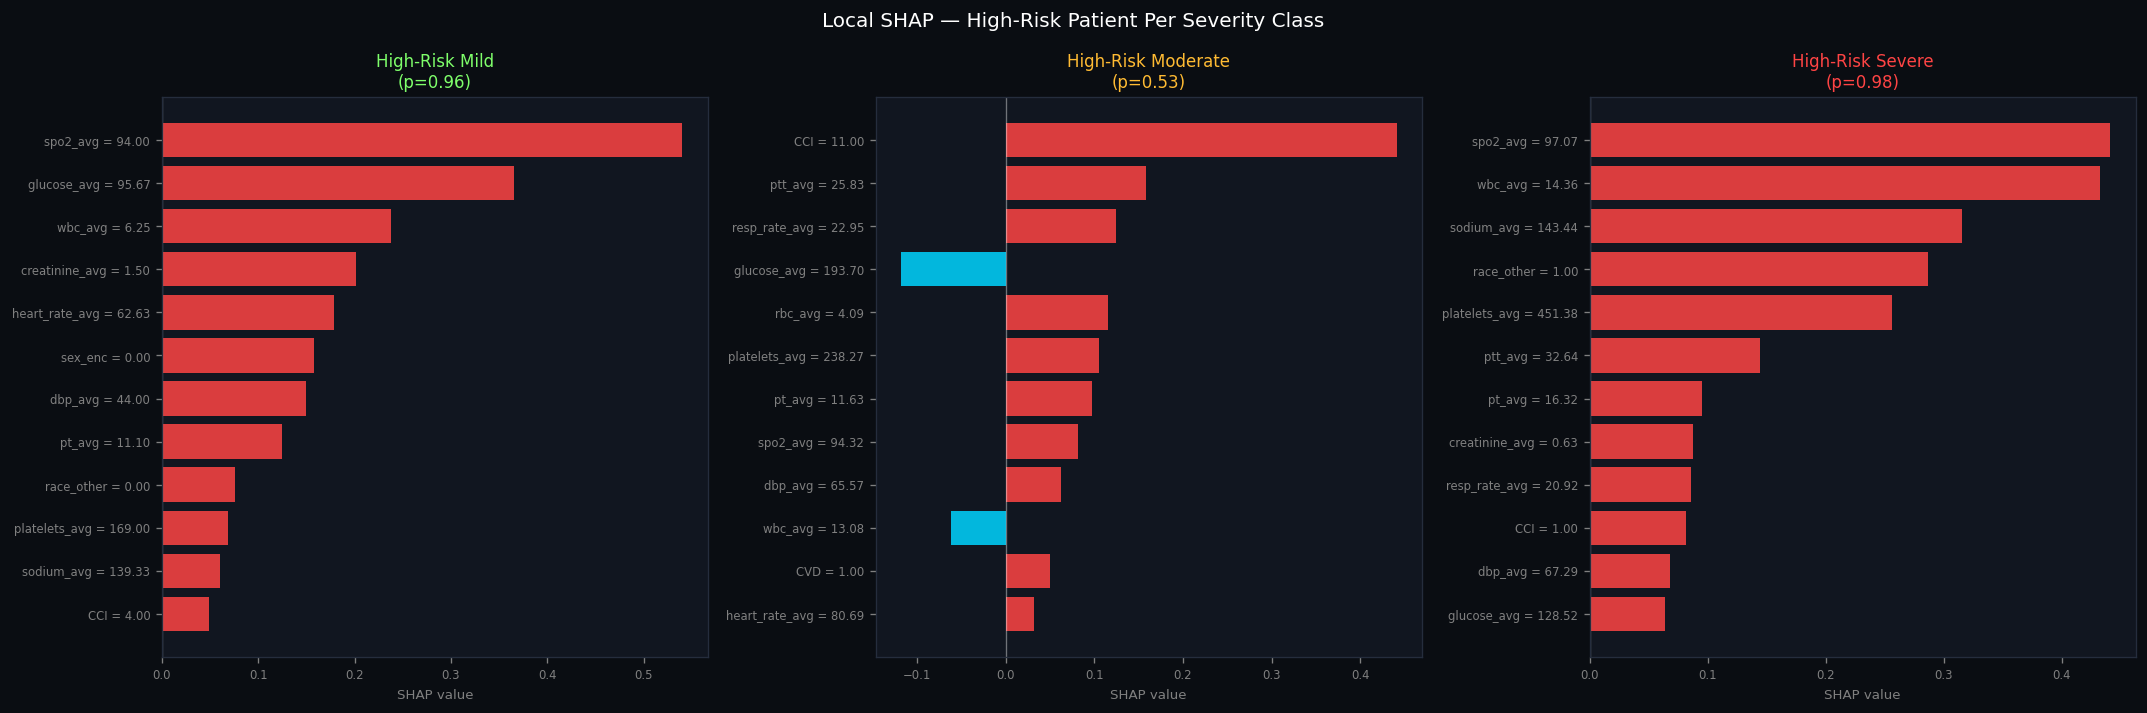


────────────────────────────────────────────────────────────
  SHAP Correlation Heatmap
────────────────────────────────────────────────────────────


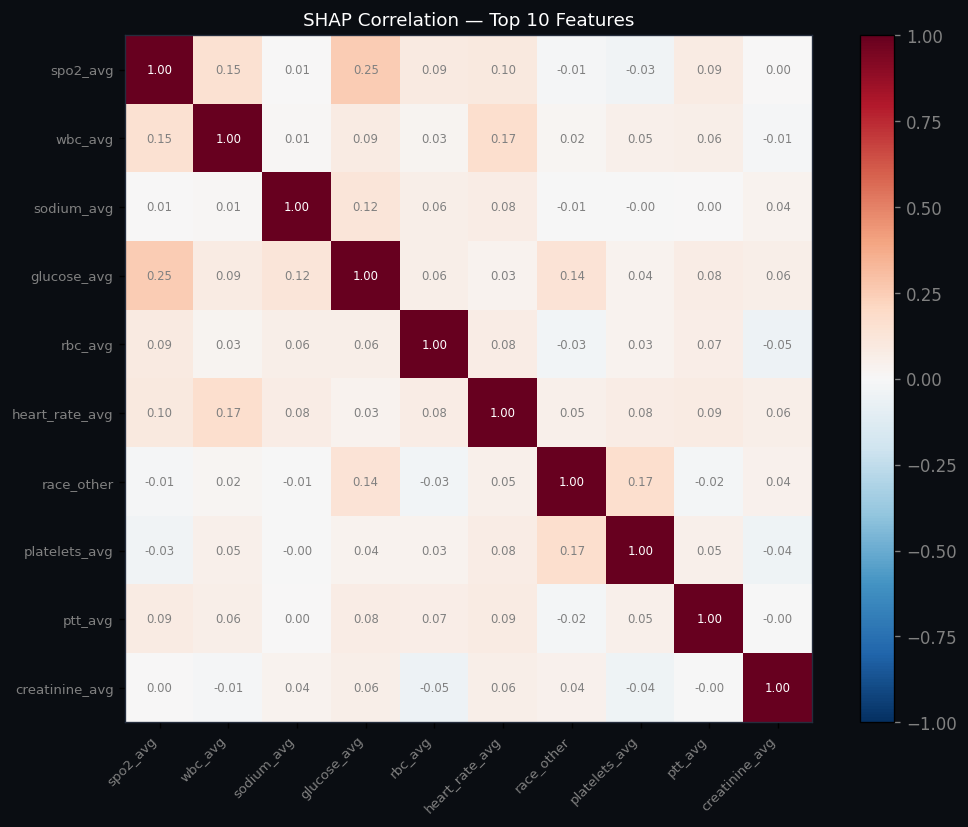


✓ Displayed 10/10 images

CLINICAL SUMMARY

Model:  XGBoost (tuned, CUDA)
Task:   TBI Severity — Mild / Moderate / Severe
AUC-ROC (test set): 0.8093

Top 5 features driving severity prediction:
  1. spo2_avg
  2. wbc_avg
  3. sodium_avg
  4. glucose_avg
  5. rbc_avg

How to read your plots:
  shap_beeswarm_severe.png  → What pushes a patient into Severe?
  shap_dependence.png       → At what threshold does risk jump?
  shap_local.png            → Why was THIS patient predicted Severe?
  shap_correlation.png      → Which features are redundant?

Next steps:
  → Calibration   : are predicted probabilities accurate?
  → Subgroup      : does performance differ by sex / race?
  → Validation    : test on a different hospital's data



In [5]:

# ────────────────────────────────────────────────────────────
# CELL 8 — SHAP Analysis
# ────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 5 — SHAP Analysis")
print("=" * 60)

print("\nComputing SHAP values...")
explainer       = shap.TreeExplainer(xgb_tuned)
shap_values_raw = explainer.shap_values(X_test)

# ── Handle both old and new SHAP output formats ───────────────
# Old SHAP (<0.40): list of arrays [class0, class1, class2]
#   each shape: (n_samples, n_features)
# New SHAP (>=0.40): single 3D array
#   shape: (n_samples, n_features, n_classes)

if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw
    print(f"  SHAP format: list of {len(shap_values)} arrays "
          f"(shape: {shap_values[0].shape})")
elif isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
    shap_values = [shap_values_raw[:, :, i]
                   for i in range(shap_values_raw.shape[2])]
    print(f"  SHAP format: 3D array → split into {len(shap_values)} class arrays")
else:
    shap_values = [shap_values_raw]
    print(f"  SHAP format: fallback single array")

n_classes = len(shap_values)
print(f"✓ SHAP computed — {n_classes} classes × "
      f"{shap_values[0].shape[0]} patients × "
      f"{shap_values[0].shape[1]} features")

assert shap_values[0].shape[1] == len(TOP_FEATURES), (
    f"SHAP features ({shap_values[0].shape[1]}) != "
    f"TOP_FEATURES ({len(TOP_FEATURES)})"
)

# ── Global importance (mean across all classes) ───────────────
mean_abs_shap = np.mean(
    [np.abs(shap_values[i]).mean(axis=0) for i in range(n_classes)],
    axis=0,
)
global_imp = pd.Series(mean_abs_shap,
                        index=TOP_FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor("#0a0d12")
ax.set_facecolor("#111620")
colors_imp = plt.cm.cool(np.linspace(0.2, 0.9, len(global_imp)))
ax.barh(range(len(global_imp)), global_imp.values[::-1],
        color=colors_imp[::-1], alpha=0.9)
ax.set_yticks(range(len(global_imp)))
ax.set_yticklabels(global_imp.index[::-1], fontsize=9)
ax.set_xlabel("Mean |SHAP| (averaged across classes)", color="gray")
ax.set_title("Global Feature Importance — TBI Severity (XGBoost)",
             color="white", fontsize=12)
ax.tick_params(colors="gray")
ax.spines[:].set_color("#252d3d")
plt.tight_layout()
plt.savefig("shap_global_importance.png", dpi=120,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: shap_global_importance.png")

# ── Beeswarm — one per severity class ────────────────────────
for i, class_name in enumerate(CLASS_NAMES):
    plt.figure(figsize=(11, 7))
    plt.gcf().patch.set_facecolor("#0a0d12")
    shap.summary_plot(shap_values[i], X_test,
                      feature_names=TOP_FEATURES,
                      show=False, plot_size=None)
    plt.title(f"SHAP Beeswarm — {class_name} TBI",
              color="white", fontsize=12, pad=12)
    plt.gca().set_facecolor("#111620")
    plt.gca().tick_params(colors="gray")
    plt.tight_layout()
    fname = f"shap_beeswarm_{class_name.lower()}.png"
    plt.savefig(fname, dpi=120, bbox_inches="tight", facecolor="#0a0d12")
    plt.close()
    print(f"✓ Saved: {fname}")

# ── Dependence plots — top 4, Severe class ───────────────────
top4          = global_imp.head(4).index.tolist()
severe_idx    = min(2, n_classes - 1)   # safe index even if <3 classes
sv_severe     = shap_values[severe_idx]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.patch.set_facecolor("#0a0d12")
axes = axes.flatten()

for i, feat in enumerate(top4):
    ax       = axes[i]
    fi       = TOP_FEATURES.index(feat)
    interact = global_imp.drop(feat).idxmax()
    sc = ax.scatter(X_test[feat].values, sv_severe[:, fi],
                    c=X_test[interact].values,
                    cmap="cool", s=8, alpha=0.5)
    ax.axhline(0, color="white", lw=0.7, alpha=0.3, linestyle="--")
    ax.set_xlabel(feat, color="gray", fontsize=9)
    ax.set_ylabel("SHAP (Severe)", color="gray", fontsize=9)
    ax.set_title(f"{feat}  (color={interact})", color="white", fontsize=9)
    ax.set_facecolor("#111620")
    ax.tick_params(colors="gray", labelsize=7)
    ax.spines[:].set_color("#252d3d")
    plt.colorbar(sc, ax=ax).ax.tick_params(colors="gray", labelsize=7)

plt.suptitle("SHAP Dependence — Severe TBI (Top 4 Features)",
             color="white", fontsize=12)
plt.tight_layout()
plt.savefig("shap_dependence.png", dpi=120,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: shap_dependence.png")

# ── Local explanations — high-risk patient per class ─────────
proba = xgb_tuned.predict_proba(X_test)

# Use actual number of classes detected in SHAP/proba
use_names  = CLASS_NAMES[:n_classes]
use_colors = ["#7fff6b", "#ffbb33", "#ff4444"][:n_classes]

fig, axes = plt.subplots(1, n_classes, figsize=(6*n_classes, 6))
fig.patch.set_facecolor("#0a0d12")

# If n_classes == 1, axes is not a list — normalize it
if n_classes == 1:
    axes = [axes]

for i, (cname, color) in enumerate(zip(use_names, use_colors)):
    ax      = axes[i]
    pidx    = np.argmax(proba[:, i])
    sv_p    = shap_values[i][pidx]
    fv_p    = X_test.iloc[pidx]

    order   = np.argsort(np.abs(sv_p))[::-1][:12]
    labels  = [f"{TOP_FEATURES[j]} = {fv_p.iloc[j]:.2f}" for j in order]
    vals    = sv_p[order]
    bcolors = ["#ff4444" if v > 0 else "#00d4ff" for v in vals]

    ax.barh(range(len(vals)), vals[::-1], color=bcolors[::-1], alpha=0.85)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(labels[::-1], fontsize=7)
    ax.axvline(0, color="white", lw=0.8, alpha=0.4)
    ax.set_title(f"High-Risk {cname}\n(p={proba[pidx, i]:.2f})",
                 color=color, fontsize=10)
    ax.set_xlabel("SHAP value", color="gray", fontsize=8)
    ax.set_facecolor("#111620")
    ax.tick_params(colors="gray", labelsize=7)
    ax.spines[:].set_color("#252d3d")

plt.suptitle("Local SHAP — High-Risk Patient Per Severity Class",
             color="white", fontsize=12)
plt.tight_layout()
plt.savefig("shap_local.png", dpi=120,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: shap_local.png")


# ── SHAP correlation heatmap ──────────────────────────────────
top10     = global_imp.head(10).index.tolist()
sv_all    = np.mean(np.stack(shap_values, axis=0), axis=0)  # safe stack
shap_corr = pd.DataFrame(sv_all, columns=TOP_FEATURES)[top10].corr()

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("#0a0d12")
ax.set_facecolor("#111620")
im = ax.imshow(shap_corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(top10)))
ax.set_xticklabels(top10, rotation=45, ha="right", fontsize=8, color="gray")
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10, fontsize=8, color="gray")
for ii in range(len(top10)):
    for jj in range(len(top10)):
        v = shap_corr.iloc[ii, jj]
        ax.text(jj, ii, f"{v:.2f}", ha="center", va="center",
                fontsize=7, color="white" if abs(v) > 0.5 else "gray")
plt.colorbar(im, ax=ax).ax.tick_params(colors="gray")
ax.set_title("SHAP Correlation — Top 10 Features",
             color="white", fontsize=11)
ax.spines[:].set_color("#252d3d")
plt.tight_layout()
plt.savefig("shap_correlation.png", dpi=120,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: shap_correlation.png")


# ────────────────────────────────────────────────────────────
# CELL 9 — Display all images
# ────────────────────────────────────────────────────────────

ALL_IMAGES = [
    ("Feature Selection",               "feature_selection.png"),
    ("Cross-Validation Results",        "model_cv_results.png"),
    ("Optuna Tuning",                   "optuna_tuning.png"),
    ("SHAP Global Importance",          "shap_global_importance.png"),
    ("SHAP Beeswarm — Mild TBI",        "shap_beeswarm_mild.png"),
    ("SHAP Beeswarm — Moderate TBI",    "shap_beeswarm_moderate.png"),
    ("SHAP Beeswarm — Severe TBI",      "shap_beeswarm_severe.png"),
    ("SHAP Dependence — Severe TBI",    "shap_dependence.png"),
    ("SHAP Local — High Risk Patients", "shap_local.png"),
    ("SHAP Correlation Heatmap",        "shap_correlation.png"),
]

print("\n" + "=" * 60)
print("ALL OUTPUT IMAGES")
print("=" * 60)

found, missing = 0, []
for title, fname in ALL_IMAGES:
    if os.path.exists(fname):
        print(f"\n{'─'*60}\n  {title}\n{'─'*60}")
        display(Image(filename=fname))
        found += 1
    else:
        missing.append(fname)

print(f"\n✓ Displayed {found}/{len(ALL_IMAGES)} images")
if missing:
    print(f"⚠ Not found: {missing}")
    print("  → Re-run the cell that generates the missing file")


# ────────────────────────────────────────────────────────────
# CELL 10 — Clinical summary
# ────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("CLINICAL SUMMARY")
print("=" * 60)
print(f"\nModel:  XGBoost (tuned, {DEVICE.upper()})")
print(f"Task:   TBI Severity — Mild / Moderate / Severe")
print(f"AUC-ROC (test set): {auc_tuned:.4f}")
print(f"\nTop 5 features driving severity prediction:")
for i, feat in enumerate(global_imp.head(5).index, 1):
    print(f"  {i}. {feat}")
print("""
How to read your plots:
  shap_beeswarm_severe.png  → What pushes a patient into Severe?
  shap_dependence.png       → At what threshold does risk jump?
  shap_local.png            → Why was THIS patient predicted Severe?
  shap_correlation.png      → Which features are redundant?

Next steps:
  → Calibration   : are predicted probabilities accurate?
  → Subgroup      : does performance differ by sex / race?
  → Validation    : test on a different hospital's data
""")
